# 02 — Automated extraction

The pipeline's *Extract* step: collect the publications of the four sources **without
manual intervention**, download the images, and write the whole thing as JSON.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))

from dotenv import load_dotenv

load_dotenv(RACINE / ".env")

from multimodal_etl.logging_setup import setup_logging

setup_logging()

## 1. One source going down must not stop the others

`collect_sources` calls each connector inside its own `try/except` and keeps a tally: the
number of publications per source, `-1` on error. That tally is what feeds the "failed
sources" indicator of the monitoring plan.

In [2]:
from multimodal_etl.config import ExtractionConfig
from multimodal_etl.extract import collect_sources

publications, bilan = collect_sources(ExtractionConfig())
print(f"{len(publications)} publications collectées")
bilan

2026-09-03 09:48:19 | INFO    | multimodal_etl.extract | Extract: starting source 'rss'


2026-09-03 09:48:19 | INFO    | multimodal_etl.sources.rss | RSS: reading feed 'the_guardian' (https://www.theguardian.com/world/rss)


2026-09-03 09:48:19 | INFO    | multimodal_etl.sources.rss | RSS: 45 publications collected from 'the_guardian'


2026-09-03 09:48:19 | INFO    | multimodal_etl.sources.rss | RSS: reading feed 'bbc_news' (https://feeds.bbci.co.uk/news/world/rss.xml)


2026-09-03 09:48:19 | INFO    | multimodal_etl.sources.rss | RSS: 22 publications collected from 'bbc_news'


...

2026-09-03 09:49:09 | INFO    | multimodal_etl.sources.kaggle_fakeddit | Fakeddit: 24 publications loaded from fakeddit_sample.tsv (demonstration sample)


2026-09-03 09:49:09 | INFO    | multimodal_etl.extract | Extract: source 'kaggle_fakeddit' -> 24 publications (ok)


2026-09-03 09:49:09 | INFO    | multimodal_etl.extract | Extract: 164 raw publications in total


164 publications collectées


{'rss': {'count': 92, 'cause': 'ok'},
 'newsdata': {'count': 0, 'cause': 'disabled'},
 'fakenewsnet': {'count': 48, 'cause': 'ok'},
 'kaggle_fakeddit': {'count': 24, 'cause': 'ok'}}

## 2. What a connector returns

Every connector produces the **same structure**, whatever the data came from. That is what
lets the next step process them uniformly.

In [3]:
import pandas as pd

df_brut = pd.DataFrame(publications)
print("Colonnes :", list(df_brut.columns))
df_brut[["source", "source_type", "access_method"]].value_counts().to_frame("publications")

Colonnes : ['source', 'source_type', 'access_method', 'title', 'text', 'url', 'image_url', 'image_source', 'published_at', 'language', 'label', 'label_source']


,,,publications
source,source_type,access_method,
rss:the_guardian,rss,rss_feed,45
rss:abc_news,rss,rss_feed,25
fakenewsnet:politifact,dataset,github_download,24
fakenewsnet:gossipcop,dataset,github_download,24
fakeddit,dataset,kaggle_download,24
rss:bbc_news,rss,rss_feed,22


## 3. Download the images, not just their URLs

An image URL proves nothing: it can be dead, gated, or point at an HTML page. So the
pipeline **downloads** each image and opens it with Pillow before keeping it. Three
checks, cheapest first: the announced MIME type, the file size, then a real decode.

It is the path of the resulting file that gets recorded next to the text.

In [4]:
from multimodal_etl.config import ImageConfig
from multimodal_etl.images import download_images

compteurs = download_images(publications, ImageConfig())
compteurs

2026-09-03 09:49:19 | WARNING | multimodal_etl.images | Image: download failed (https://s.abcnews.com/images/International/wirestory_117ececb1e1fa4b4084fa0938ce): 403 Client Error: Forbidden for url: https://s.abcnews.com/images/International/wirestory_117ececb1e1fa4b4084fa0938ce9943d_4x3_384.jpg


2026-09-03 09:49:21 | WARNING | multimodal_etl.images | Image: download failed (http://nationalreport.net/wp-content/uploads/2016/05/Target.jpg): 404 Client Error: Not Found for url: https://nationalreport.net/wp-content/uploads/2016/05/Target.jpg


2026-09-03 09:49:27 | INFO    | multimodal_etl.images | Images: 125 downloaded, 2 failures, 37 skipped (10.3 MB on disk)


{'attempted': 127,
 'succeeded': 125,
 'failed': 2,
 'skipped': 37,
 'bytes': 10829079}

In [5]:
avec_fichier = [p for p in publications if p.get("image_path")]
print(f"{len(avec_fichier)} publications ont bien un fichier image")
exemple = avec_fichier[0]
print("Texte :", exemple["title"][:88])
print("Image :", exemple["image_path"])

125 publications ont bien un fichier image
Texte : New constitution in Guinea-Bissau will undermine democracy, opponents say
Image : data/raw/images/915abf9ba6238c7a.jpg


The text / image pair, shown as it will be handed to the model:

New constitution in Guinea-Bissau will undermine democracy, opponents say


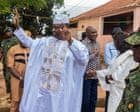

In [6]:
from IPython.display import Image, display

from multimodal_etl.config import absolute_path

print(exemple["title"])
display(Image(filename=str(absolute_path(exemple["image_path"])), width=420))

## 4. Saving the raw data

The format chosen is **JSON**, not CSV: a multimodal publication pairs a text with a file
path, and JSON keeps that structure unambiguous. The recorded path is **relative to the
project root**, so it stays valid somewhere other than the machine that produced it — the
pipeline runs locally as well as inside an Airflow container.

In [7]:
import json

from multimodal_etl.extract import save_raw

chemin_brut = save_raw(publications)
print("Écrit dans :", chemin_brut)
print(json.dumps(exemple, ensure_ascii=False, indent=2)[:600])

2026-09-03 09:49:27 | INFO    | multimodal_etl.extract | Extract: 164 publications written to data\raw\raw_publications_20260903_074927.json


Écrit dans : data\raw\raw_publications_20260903_074927.json
{
  "source": "rss:the_guardian",
  "source_type": "rss",
  "access_method": "rss_feed",
  "title": "New constitution in Guinea-Bissau will undermine democracy, opponents say",
  "text": "<p>Referendum result means fewer seats in parliament and new rules on candidates, ahead of December elections</p><p>Guinea-Bissau voters have approved a new constitution, which critics say will undermine democracy, that significantly expands presidential powers ahead of elections due in December.</p><p>According to provisional results, 70% of voters approved sweeping changes in the tiny west African state’s f
